# **Imports** 📓

In [ ]:
import os
import sys
import shutil
import gc
import hashlib
from glob import glob
from pprint import pprint
from collections import Counter, defaultdict


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from PIL import Image
import cv2
from tensorflow.keras.utils import load_img


from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



 # **EDA** 📊

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rahasahly/oct2017")

#{"username":"elafalmalki","key":"b76fe0d3245668efb211a913c70c1583"}


#Rha Sahly
#71ce9a4fe0f0ca4ac0c01ac12cbc497a


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: elafalmalki
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rahasahly/oct2017


100%|██████████| 5.41G/5.41G [04:56<00:00, 19.6MB/s]


In [ ]:
training_dir = "/content/oct2017/OCT2017/train"
testing_dir = "/content/oct2017/OCT2017/test"

**Define label mapping**

In [ ]:
#mapping
label_to_class_mapping = {
    'CNV': 0,
    'DME': 1,
    'DRUSEN': 2,
    'NORMAL': 3
}


class_to_label_mapping = {v: k for k, v in label_to_class_mapping.items()}

**Load dataset**

In [ ]:
                                                                                              #load dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    training_dir,
    label_mode='categorical',
    labels='inferred',
    class_names=list(label_to_class_mapping.keys()),
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    testing_dir,
    label_mode='categorical',
    labels='inferred',
    class_names=list(label_to_class_mapping.keys()),
    shuffle=False
)

Found 83484 files belonging to 4 classes.
Found 1000 files belonging to 4 classes.


In [ ]:

train_labels = []
for _, label_batch in train_dataset:
    train_labels.extend(np.argmax(label_batch.numpy(), axis=-1))  #convert one-hot to class index

final_test_labels = []
for _, label_batch in test_dataset:
    final_test_labels.extend(np.argmax(label_batch.numpy(), axis=-1))  #convert one-hot to class index


In [ ]:

print("Unique labels in training set:", np.unique(train_labels))
print("Unique labels in testing set:", np.unique(final_test_labels))

Unique labels in training set: [0 1 2 3]
Unique labels in testing set: [0 1 2 3]


**converting labels to integers for easier handling** + **ensure unified mapping for consistency**

In [ ]:

print("Unified Label to Index Mapping:", label_to_class_mapping)
print("Unique labels in training labels:", set(train_labels))
print("Unique labels in final test labels:", set(final_test_labels))


Unified Label to Index Mapping: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
Unique labels in training labels: {0, 1, 2, 3}
Unique labels in final test labels: {0, 1, 2, 3}


In [ ]:
print("Is train_paths defined?", 'train_paths' in locals())


Is train_paths defined? False


In [ ]:
image_paths = []
labels = []

for label_dir in os.listdir(training_dir):
    label_path = os.path.join(training_dir, label_dir)
    if os.path.isdir(label_path):
        for img_file in os.listdir(label_path):
            image_paths.append(os.path.join(label_path, img_file))
            labels.append(label_dir)


In [ ]:
for i in range(5):
    print(f"Sample {i}: {image_paths[i]} → {labels[i]}")


Sample 0: /content/oct2017/OCT2017/train/CNV/CNV-3453634-58.jpeg → CNV
Sample 1: /content/oct2017/OCT2017/train/CNV/CNV-1188386-198.jpeg → CNV
Sample 2: /content/oct2017/OCT2017/train/CNV/CNV-6106345-113.jpeg → CNV
Sample 3: /content/oct2017/OCT2017/train/CNV/CNV-6666538-113.jpeg → CNV
Sample 4: /content/oct2017/OCT2017/train/CNV/CNV-3514723-83.jpeg → CNV


# **Detect and remove duplicates**

In [ ]:

import hashlib


def compute_image_hash(image_path, chunk_size=8192):
    hasher = hashlib.md5()
    try:
        with open(image_path, 'rb') as f:
            for chunk in iter(lambda: f.read(chunk_size), b""):
                hasher.update(chunk)
    except Exception as e:
        print(f"Error reading {image_path}: {e}")
        return None
    return hasher.hexdigest()


#---------------------------------------------------------------

def remove_duplicates(image_paths, labels):
    seen_hashes = set()
    unique_image_paths = []
    unique_labels = []
    duplicates = []

    for i, image_path in enumerate(image_paths):
        image_hash = compute_image_hash(image_path)

        if image_hash is None:
            continue

        if image_hash not in seen_hashes:
            seen_hashes.add(image_hash)
            unique_image_paths.append(image_path)
            unique_labels.append(labels[i])
        else:
            duplicates.append(image_path)

    print(f"Found {len(duplicates)} duplicate images.")
    return unique_image_paths, unique_labels, duplicates

In [ ]:
image_paths = []
labels = []

for label_dir in os.listdir(training_dir):
    label_path = os.path.join(training_dir, label_dir)
    if os.path.isdir(label_path):
        for img_file in os.listdir(label_path):
            image_paths.append(os.path.join(label_path, img_file))
            labels.append(label_dir)

labels = np.array([label_to_class_mapping[label] for label in labels], dtype=np.int32)


In [ ]:

print("removing duplicates in the dataset")
unique_image_paths, unique_labels, duplicates = remove_duplicates(image_paths, labels)


image_paths = unique_image_paths
labels = unique_labels

assert len(image_paths) == len(labels), "Mismatch between image paths and labels after duplicate removal!"

print(f" Dataset size after duplicate removal: {len(image_paths)} images.")
print(f" Unique paths after duplicate removal: {len(set(image_paths))}")
print(f" Number of labels after duplicate removal: {len(labels)}")

if len(labels) != len(image_paths):
    print(f" Mismatch detected: {len(labels)} labels vs {len(image_paths)} image paths!")

removing duplicates in the dataset
Found 6987 duplicate images.
 Dataset size after duplicate removal: 76497 images.
 Unique paths after duplicate removal: 76497
 Number of labels after duplicate removal: 76497


In [ ]:
train_labels = np.array(unique_labels, dtype=np.int32)

print(f"Final image count: {len(image_paths)}")
print(f"Final label count: {len(train_labels)}")  # Should be the same (76,497)


Final image count: 76497
Final label count: 76497


**classes distrubtion to check class imbalance**

In [ ]:
train_class_counts = Counter(unique_labels)

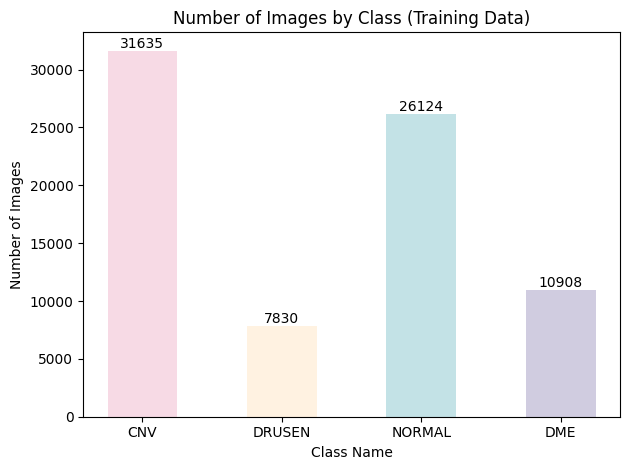

In [ ]:
# Plot class distribution
colors = ['#F7DAE5', '#FFF2E1', '#C3E2E6', '#D0CCE0']
train_class_counts_named = {class_to_label_mapping[key]: value for key, value in train_class_counts.items()}

plt.bar(train_class_counts_named.keys(), train_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Training Data)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")

# Add count labels above bars
for i, (class_name, count) in enumerate(train_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


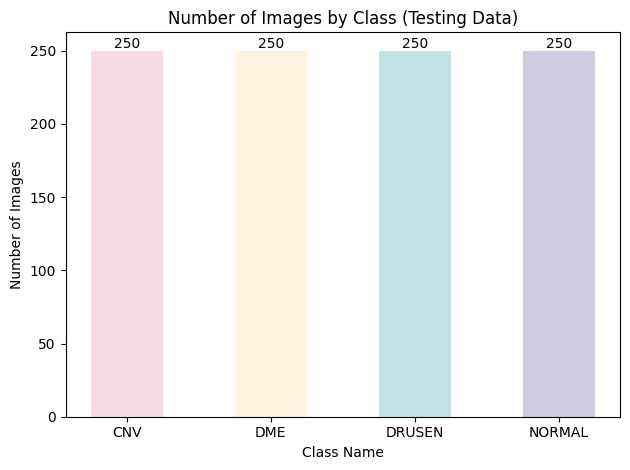

In [ ]:
test_class_counts = Counter(final_test_labels)

# Always use class_to_label_mapping
test_class_counts_named = {class_to_label_mapping[key]: value for key, value in test_class_counts.items()}

# Plot test data class distribution
plt.bar(test_class_counts_named.keys(), test_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Testing Data)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")

# Add count labels above bars
for i, (class_name, count) in enumerate(test_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# **splitting data to 70/15/15 and combining original testing with new one**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from collections import Counter

In [ ]:
def load_data_from_directory(directory_path):
    image_paths, labels = [], []
    for label_dir in os.listdir(directory_path):
        label_path = os.path.join(directory_path, label_dir)
        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                image_paths.append(os.path.join(label_path, img_file))
                labels.append(label_to_class_mapping[label_dir])
    return image_paths, labels


In [ ]:

image_paths, train_labels = load_data_from_directory(training_dir)
train_labels = np.array(train_labels, dtype=np.int32)

In [ ]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, train_labels, test_size=0.3, stratify=train_labels, random_state=42
)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.2, stratify=train_labels, random_state=42
)


In [ ]:

original_test_paths, original_test_labels = load_data_from_directory(testing_dir)
original_test_labels = np.array(original_test_labels, dtype=np.int32)


final_test_paths = np.concatenate([test_paths, original_test_paths])
final_test_labels = np.concatenate([test_labels, original_test_labels])


unique_classes, class_counts = np.unique(final_test_labels, return_counts=True)
min_samples_per_class = min(class_counts)


In [ ]:
balanced_test_paths = []
balanced_test_labels = []


In [ ]:
for class_label in unique_classes:
    class_indices = np.where(final_test_labels == class_label)[0]
    selected_indices = np.random.choice(class_indices, min_samples_per_class, replace=False)
    balanced_test_paths.extend(final_test_paths[selected_indices])
    balanced_test_labels.extend(final_test_labels[selected_indices])



In [ ]:

balanced_test_paths = np.array(balanced_test_paths)
balanced_test_labels = np.array(balanced_test_labels)



In [ ]:
print(f" Training paths: {len(train_paths)}")
print(f" Validation paths: {len(val_paths)}")
print(f" Testing paths (balanced): {len(balanced_test_paths)}")

print(" Training class distribution:", Counter(train_labels))
print(" Validation class distribution:", Counter(val_labels))
print(" Testing class distribution (balanced):", Counter(balanced_test_labels))


 Training paths: 46750
 Validation paths: 11688
 Testing paths (balanced): 11340
 Training class distribution: Counter({0: 20834, 3: 14736, 1: 6355, 2: 4825})
 Validation class distribution: Counter({0: 5209, 3: 3684, 1: 1589, 2: 1206})
 Testing class distribution (balanced): Counter({0: 2835, 1: 2835, 2: 2835, 3: 2835})


In [ ]:
train_labels = np.array(train_labels, dtype=np.int32)
val_labels = np.array(val_labels, dtype=np.int32)
balanced_test_labels = np.array(balanced_test_labels, dtype=np.int32)

train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((balanced_test_paths, balanced_test_labels))


In [ ]:
print(f" Training dataset: {len(list(train_dataset))} samples")
print(f" Validation dataset: {len(list(val_dataset))} samples")
print(f" Testing dataset (balanced): {len(list(test_dataset))} samples")

 Training dataset: 46750 samples
 Validation dataset: 11688 samples
 Testing dataset (balanced): 11340 samples


# **classes distrubtion**

In [ ]:
index_to_label = {0: 'CNV', 1: 'DME', 2: 'DRUSEN', 3: 'NORMAL'}


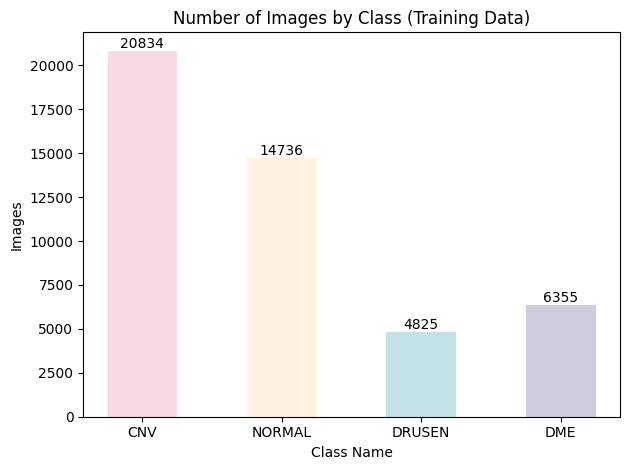

In [ ]:
                                                              #training data distribution

train_class_counts = Counter(train_labels)
train_class_counts_named = {index_to_label[key]: value for key, value in train_class_counts.items()}

colors = ['#F7DAE5', '#FFF2E1', '#C3E2E6', '#D0CCE0']
plt.bar(train_class_counts_named.keys(), train_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Training Data)")
plt.xlabel("Class Name")
plt.ylabel("Images")
for i, (class_name, count) in enumerate(train_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')
plt.tight_layout()
plt.show()

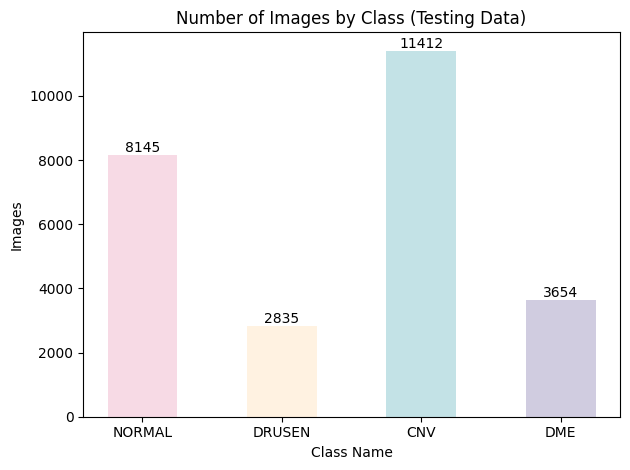

In [ ]:
                                                              #testing data distribution
test_class_counts = Counter(final_test_labels)
test_class_counts_named = {index_to_label[key]: value for key, value in test_class_counts.items()}

plt.bar(test_class_counts_named.keys(), test_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Testing Data)")
plt.xlabel("Class Name")
plt.ylabel("Images")
for i, (class_name, count) in enumerate(test_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')
plt.tight_layout()
plt.show()

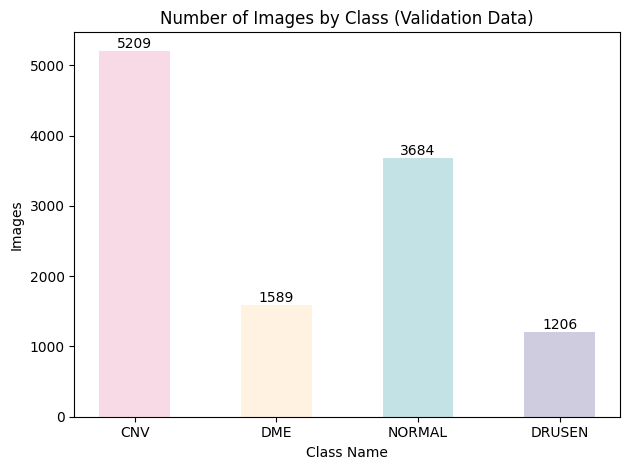

In [ ]:
                                                              #val data distribution

val_class_counts = Counter(val_labels)
val_class_counts_named = {index_to_label[key]: value for key, value in val_class_counts.items()}

plt.bar(val_class_counts_named.keys(), val_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Validation Data)")
plt.xlabel("Class Name")
plt.ylabel("Images")
for i, (class_name, count) in enumerate(val_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')
plt.tight_layout()
plt.show()

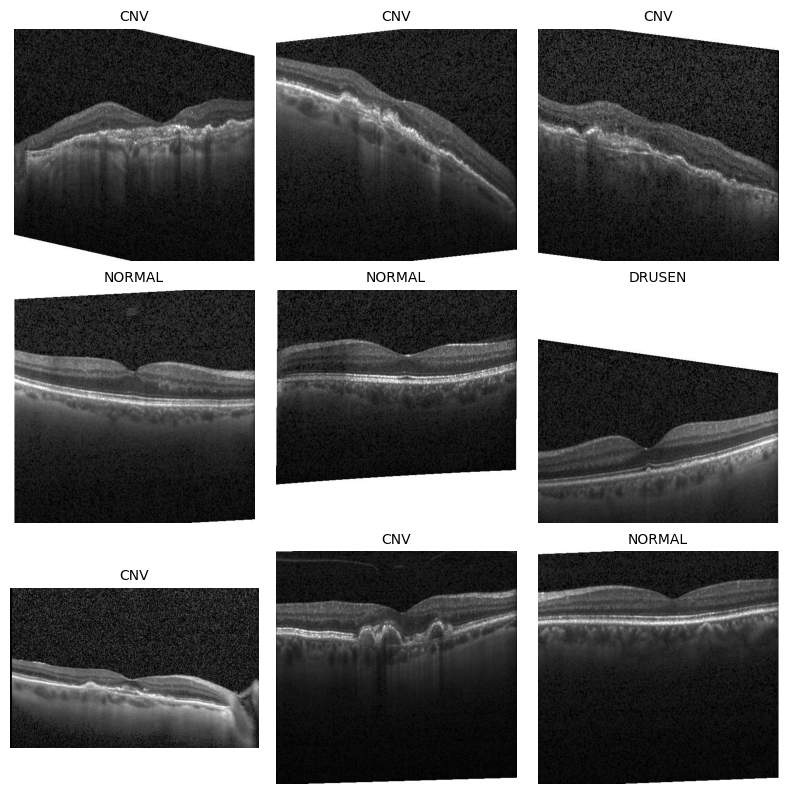

In [ ]:
from tensorflow.keras.utils import load_img

fig, axes = plt.subplots(3, 3, figsize=(8, 8), facecolor="white")
axes = axes.flatten()

for i, (image_path, label) in enumerate(train_dataset.take(9)):
    img = load_img(image_path.numpy().decode('utf-8'))
    axes[i].imshow(img, cmap="gray")
    class_name = index_to_label[int(label.numpy())]
    axes[i].set_title(f"{class_name}", fontsize=10, color="black")
    axes[i].axis("off")

plt.tight_layout(pad=1.0)
plt.show()


In [ ]:
print("Label Mapping:", label_to_class_mapping)
print("Unique labels in train set:", set(train_labels))
print("Unique labels in validation set:", set(val_labels))
print("Unique labels in test set:", set(final_test_labels))


Label Mapping: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
Unique labels in train set: {0, 1, 2, 3}
Unique labels in validation set: {0, 1, 2, 3}
Unique labels in test set: {0, 1, 2, 3}


In [ ]:
assert len(train_paths) == len(train_labels), "Mismatch in training data!"
assert len(val_paths) == len(val_labels), "Mismatch in validation data!"
assert len(final_test_paths) == len(final_test_labels), "Mismatch in test data!"

print(f"✅ Training samples: {len(train_paths)}")
print(f"✅ Validation samples: {len(val_paths)}")
print(f"✅ Testing samples: {len(final_test_paths)}")


✅ Training samples: 46750
✅ Validation samples: 11688
✅ Testing samples: 26046


# **Preproccesing**

In [ ]:
def refine_cropping(image):
    image = tf.cast(image, tf.float32)
    histogram = tf.histogram_fixed_width(image, [0, 255], nbins=256)
    peak_intensity = tf.argmax(histogram[-50:]) + 175
    threshold = tf.cast(peak_intensity - 10, tf.float32)
    binary_mask = tf.where(image >= threshold, 255.0, 0.0)

    non_white_coords = tf.where(binary_mask < 255.0)
    ymin = tf.cast(tf.reduce_min(non_white_coords[:, 0]), tf.int32)
    ymax = tf.cast(tf.reduce_max(non_white_coords[:, 0]), tf.int32)
    xmin = tf.cast(tf.reduce_min(non_white_coords[:, 1]), tf.int32)
    xmax = tf.cast(tf.reduce_max(non_white_coords[:, 1]), tf.int32)

    image_shape = tf.shape(image)
    margin = tf.minimum(20, tf.minimum(ymin, xmin))
    ymin = tf.maximum(0, ymin - margin)
    ymax = tf.minimum(image_shape[0], ymax + margin)
    xmin = tf.maximum(0, xmin - margin)
    xmax = tf.minimum(image_shape[1], xmax + margin)

    cropped_image = tf.image.crop_to_bounding_box(tf.cast(image, tf.uint8), ymin, xmin, ymax - ymin, xmax - xmin)

    return cropped_image

In [ ]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=1)

    cropped_image = refine_cropping(image)


    blurred_image = tf.image.adjust_contrast(cropped_image, contrast_factor=2.0)


    sharpened_image = tf.image.adjust_contrast(blurred_image, contrast_factor=1.5)


    resized_image = tf.image.resize(sharpened_image, [224, 224], method=tf.image.ResizeMethod.BICUBIC)


    normalized_image = resized_image / 255.0


    rgb_image = tf.image.grayscale_to_rgb(normalized_image)

    return rgb_image, label

In [ ]:

train_dataset_processed = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset_processed = val_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset_processed = test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset_processed = train_dataset_processed.batch(16).prefetch(tf.data.AUTOTUNE)
val_dataset_processed = val_dataset_processed.batch(16).prefetch(tf.data.AUTOTUNE)
test_dataset_processed = test_dataset_processed.batch(16).prefetch(tf.data.AUTOTUNE)



In [ ]:

for img_batch, lbl_batch in train_dataset_processed.take(1):
    print(f"Batch shape: {img_batch.shape}")
    print(f"Label batch shape: {lbl_batch.shape}")



Batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


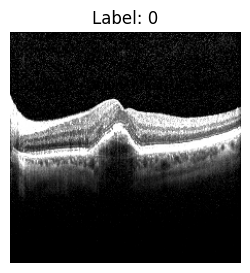

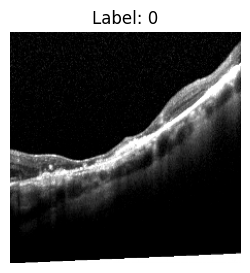

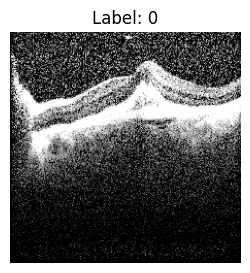

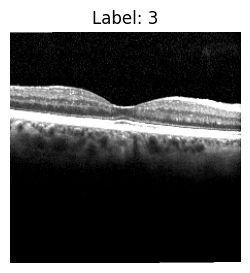

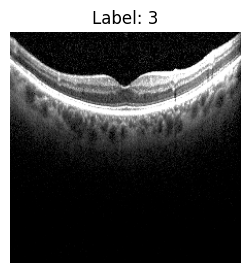

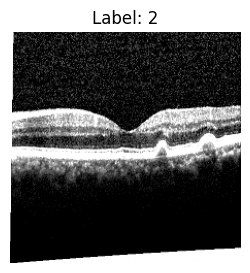

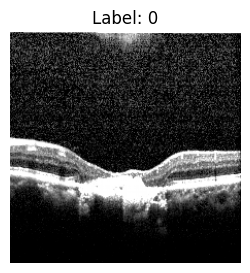

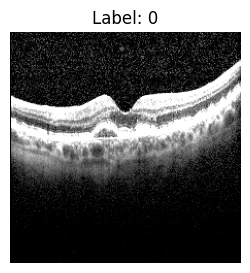

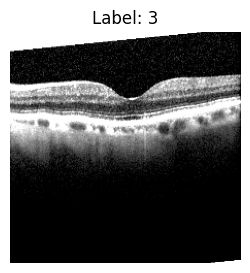

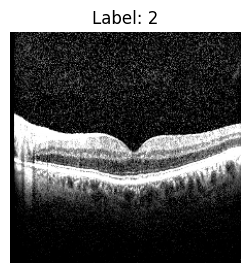

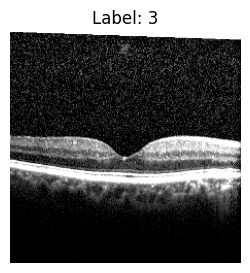

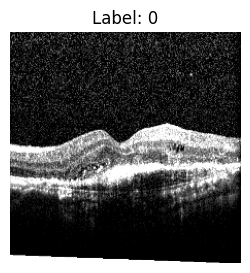

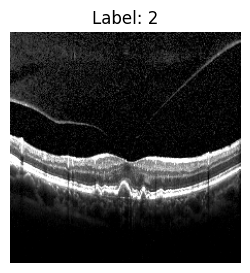

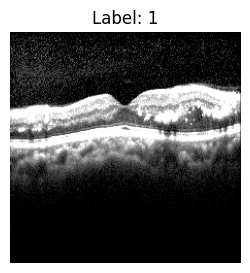

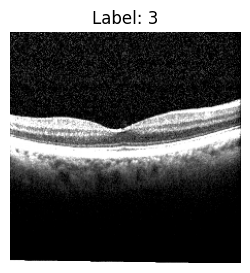

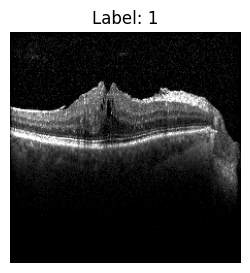

In [ ]:
for img_batch, lbl_batch in train_dataset_processed.take(1):
    for i in range(img_batch.shape[0]):
        img = img_batch[i].numpy()

        if img.ndim == 3:
            img = np.expand_dims(img, axis=0)


        img = np.clip(img, 0.0, 1.0)


        plt.figure(figsize=(3, 3))
        plt.imshow(img[0])
        plt.title(f"Label: {lbl_batch[i].numpy()}")
        plt.axis('off')
        plt.show()



In [ ]:
from collections import Counter


batch_labels = [label.numpy() for _, label in train_dataset_processed.unbatch()]
batch_label_counts = Counter(batch_labels)

print("Processed Dataset Class Distribution:")
print(batch_label_counts)



Processed Dataset Class Distribution:
Counter({0: 20834, 3: 14736, 1: 6355, 2: 4825})


In [ ]:
print("Train dataset batches:", len(train_dataset_processed))
print("Validation dataset batches:", len(val_dataset_processed))


Train dataset batches: 2922
Validation dataset batches: 731


# DenseNet201 model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
import math

#functions for scheduling learning rate
def cosine_decay(epoch, total_epochs=20, alpha=0.01):
    cosine_decay = 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))
    return float((1 - alpha) * cosine_decay + alpha)

def warmup(epoch, lr):
    if epoch < 5:
        return float(lr * (epoch + 1) / 5)
    return float(lr)

#build model
def build_optimized_model(input_shape=(224, 224, 3), num_classes=4):
    base_model = DenseNet201(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    for layer in base_model.layers[:80]:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='swish', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.7)(x)
    x = layers.Dense(256, activation='swish', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_optimized_model()

#Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
        mode='max'
    ),
    LearningRateScheduler(lambda epoch: float(warmup(epoch, 1e-4) * cosine_decay(epoch)))
]

#training
history = model.fit(
    train_dataset_processed,
    epochs=30,
    batch_size=64,
    validation_data=val_dataset_processed,
    callbacks=callbacks
)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/30
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 873s 181ms/step - accuracy: 0.6515 - loss: 1.4225 - val_accuracy: 0.9357 - val_loss: 0.4064 - learning_rate: 2.0000e-05
Epoch 2/30
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 250s 85ms/step - accuracy: 0.8929 - loss: 0.5575 - val_accuracy: 0.9421 - val_loss: 0.3596 - learning_rate: 3.9756e-05
Epoch 3/30
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 253s 86ms/step - accuracy: 0.9245 - loss: 0.4421 - val_accuracy: 0.9480 - val_loss: 0.3400 - learning_rate: 5.8546e-05
Epoch 4/30
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 250s 86ms/step - accuracy: 0.9420 - loss: 0.3724 - val_accuracy: 0.9268 - val_loss: 0.4426 - learning_rate: 7.5684e-05
Epoch 5/30
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 253s 87ms/step - accuracy: 0.9520 - loss: 0.3250 - val_accuracy: 0.9518 - val_loss: 0.3428 - learning_rate: 9.0546e-05
Epoch 6/30
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 253s 87ms/step - accuracy: 0.9678 - loss: 0.2670 - val_accuracy: 0.9397 - val_loss: 0.3311 - learning

In [ ]:
model.save('DenseNet201_model_5.h5')

In [ ]:
model.save_weights('DenseNet201_5_model.weights.h5')

In [ ]:
from google.colab import files
files.download('DenseNet201_5_model.weights.h5')
files.download('DenseNet201_model_5.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset_processed)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

709/709 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9611 - loss: 0.2832
Test Loss: 0.3570139408111572
Test Accuracy: 0.9492063522338867


In [ ]:
val_loss, val_accuracy = model.evaluate(val_dataset_processed)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

731/731 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.9635 - loss: 0.2756
Validation Loss: 0.2681
Validation Accuracy: 0.9655


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix:\n{cm}")
print(f"Total samples in confusion matrix: {cm.sum()}")


Confusion Matrix:
[[2785   15   34    1]
 [  65 2685    8   77]
 [ 166   13 2516  140]
 [   6   20   31 2778]]
Total samples in confusion matrix: 11340


In [ ]:
print(f"Data type of y_true: {type(y_true[0])}")
print(f"Data type of y_pred: {type(y_pred[0])}")


Data type of y_true: <class 'numpy.int32'>
Data type of y_pred: <class 'numpy.int64'>


In [ ]:
y_true = [int(label) for label in y_true]
y_pred = [int(label) for label in y_pred]


In [ ]:

true_counts = Counter(y_true)
pred_counts = Counter(y_pred)

print(f"True label counts: {true_counts}")
print(f"Predicted label counts: {pred_counts}")


True label counts: Counter({0: 2835, 1: 2835, 2: 2835, 3: 2835})
Predicted label counts: Counter({0: 3022, 3: 2996, 1: 2733, 2: 2589})


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["CNV", "DME", "DRUSEN", "NORMAL"]))



              precision    recall  f1-score   support

         CNV       0.92      0.98      0.95      2835
         DME       0.98      0.95      0.96      2835
      DRUSEN       0.97      0.89      0.93      2835
      NORMAL       0.93      0.98      0.95      2835

    accuracy                           0.95     11340
   macro avg       0.95      0.95      0.95     11340
weighted avg       0.95      0.95      0.95     11340



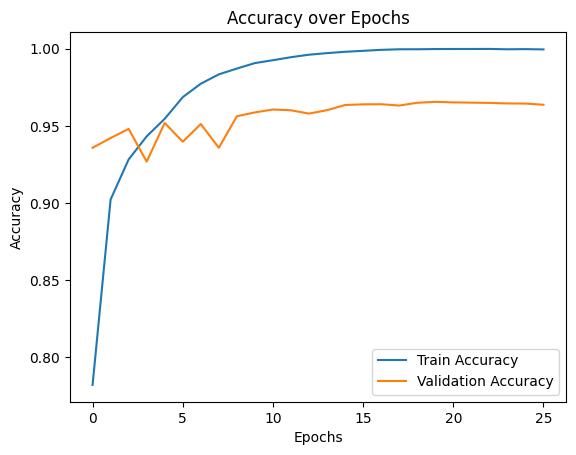

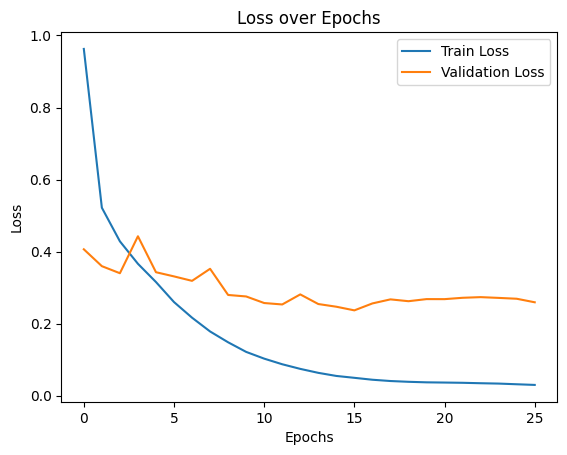

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

[[2785   15   34    1]
 [  65 2685    8   77]
 [ 166   13 2516  140]
 [   6   20   31 2778]]


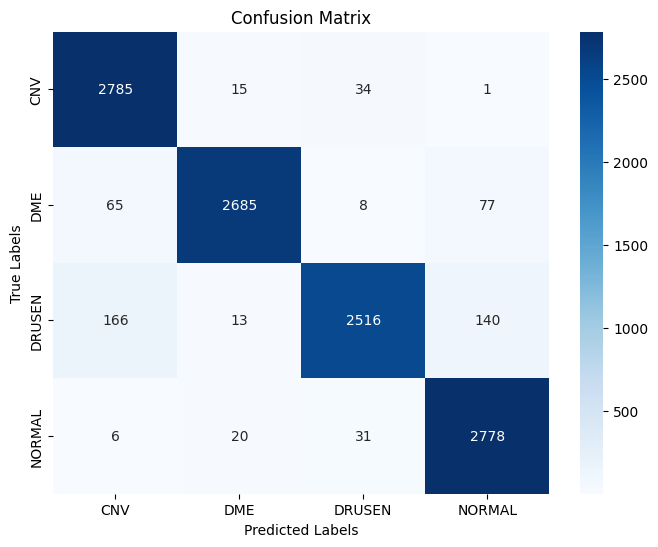

In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset_processed:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)
print(cm)

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
